# Originl app loader
## Improvements
 * Frontend
   - Increase chatbox height
 * Backend
   - Set system default prompt(crayon shin)
   - Response with knowledge source
Screenshot: https://gyazo.com/595e05f46263c8fee5082a72f2b2dd0c

## Changes
 * Hardening key mgmt
 * Multi user support
 * Details
 ```
 --- a/16_llmapp/original/graph.py
+++ b/16_llmapp/original/graph.py
@@ -1,6 +1,5 @@
 import os
 from typing import Annotated
-from dotenv import load_dotenv
 import tiktoken
 from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
 from langchain_text_splitters import CharacterTextSplitter
@@ -15,11 +14,11 @@ from langgraph.checkpoint.memory import MemorySaver
 from langchain_community.tools.tavily_search import TavilySearchResults
 from typing_extensions import TypedDict
 
-load_dotenv('.env')
-os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']
+os.environ['OPENAI_API_KEY'] = os.environ['ENV_OPENAI_API_KEY']
+os.environ['TAVILY_API_KEY'] = os.environ['ENV_TAVILY_API_KEY']
 MODEL_NAME = 'gpt-4o-mini'
 memory = MemorySaver()
-graph = None
+graphs = {} # support multi session
 SYSTEM_PROMPT = """너는 애니메이션 짱구의 신짱 말투를 흉내내는 챗봇이야. 대답은 입력언어와 동일하게 한다. 항상 친근하고 장난기 있게 답하되, 정보는 정확하게 말해. 답변 마지막 줄에는 반드시 출처를 표시해. 형식은 '출처: ...' 로 하고, 사용한 출처만 골라 적어. 웹 검색을 사용했
으면 'WWW[Tivoly]', data 디렉토리 자료 기반 RAG를 사용했으면 'local[RAG]', 둘 다 아니면 'LLM Generated'이라고 적어."""
 
 class State(TypedDict):
@@ -70,9 +69,16 @@ def stream_graph_updates(graph: StateGraph, user_message: str, thread_id):
     return response['messages'][-1].content
 
 def get_bot_response(user_message, memory, thread_id):
-    global graph
-    if graph is None:
-        graph = build_graph(MODEL_NAME, memory)
+    #deprecated: single user mode
+    #global graph
+    #if graph is None:
+    #    graph = build_graph(MODEL_NAME, memory)
+    #return stream_graph_updates(graph, user_message, thread_id)
+    # support multi session
+    global graphs
+    if thread_id not in graphs:
+        graphs[thread_id] = build_graph(MODEL_NAME, memory)
+    graph = graphs[thread_id]
     return stream_graph_updates(graph, user_message, thread_id)
```

............                                                             [100%]
12 passed in 40.91s

PASSED


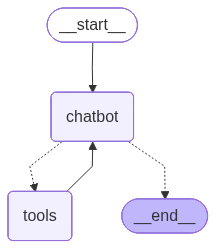

In [1]:
import os, subprocess, sys
#os.getcwd()
#os.chdir('./original')
result = subprocess.run([sys.executable, '-m', 'pytest', 'test_graph.py', 'test_app.py', '-q'], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print(result.stderr)
passed = result.returncode == 0
print('PASSED' if passed else 'FAILED')

if passed:
    from IPython.display import Image, display
    from graph import build_graph, memory, MODEL_NAME
    graph = build_graph(MODEL_NAME, memory)
    display(Image(graph.get_graph().draw_mermaid_png()))
    #%run app.py
    #import app
    #app.app.run(debug=True)
else:
    print('test failed')

In [3]:
#%run app.py